In [39]:
# Read “sequence.fa" genome fasta file using Biopython #
!pip install biopython
from Bio import SeqIO
for seq_rec in SeqIO.parse("sequence.fa","fasta"):
    print(seq_rec.name)
    print(seq_rec.seq)
print(type(seq_rec.name))
print(type(seq_rec.seq))
seq_str = str(seq_rec.seq)
print(seq_str)
print(type(seq_str))

# Read "transcriptome.fa" genome fasta file using Biopython wihch will be used in "Translation" Part Below #

!pip install biopython
from Bio import SeqIO
import re
transcriptome_rna_dictionary = {} # Build a RNA dictionary with every gene name in file "transcriptome" #
for transcriptome in SeqIO.parse("transcriptome.fa","fasta"):
    transcriptome_description = str(transcriptome.description)
    transcriptome_dna_sequence = str(transcriptome.seq)
    transcriptome_rna_sequence = transcriptome_dna_sequence.replace("T","U")
    search = re.search(r"\[gene=(.+?)\]",transcriptome.description)
    if search:
        transcriptome_name = search.group(1)
        transcriptome_rna_dictionary[transcriptome_name] = transcriptome_rna_sequence # delete unwanted descriptions, leaving gene names only #
print(transcriptome_rna_dictionary)

NC_045512.2
...
<class 'str'>
<class 'Bio.Seq.Seq'>
...
<class 'str'>
{'ORF1ab': '...', 'S': 'AUGUUUGUUUUUCUUGUUUUAUUGCCACUAGUCUCUAGUCAGUGUGUUAAUCUUACAACCAGAACUCAAUUACCCCCUGCAUACACUAAUUCUUUCACACGUGGUGUUUAUUACCCUGACAAAGUUUUCAGAUCCUCAGUUUUACAUUCAACUCAGGACUUGUUCUUACCUUUCUUUUCCAAUGUUACUUGGUUCCAUGCUAUACAUGUCUCUGGGACCAAUGGUACUAAGAGGUUUGAUAACCCUGUCCUACCAUUUAAUGAUGGUGUUUAUUUUGCUUCCACUGAGAAGUCUAACAUAAUAAGAGGCUGGAUUUUUGGUACUACUUUAGAUUCGAAGACCCAGUCCCUACUUAUUGUUAAUAACGCUACUAAUGUUGUUAUUAAAGUCUGUGAAUUUCAAUUUUGUAAUGAUCCAUUUUUGGGUGUUUAUUACCACAAAAACAACAAAAGUUGGAUGGAAAGUGAGUUCAGAGUUUAUUCUAGUGCGAAUAAUUGCACUUUUGAAUAUGUCUCUCAGCCUUUUCUUAUGGACCUUGAAGGAAAACAGGGUAAUUUCAAAAAUCUUAGGGAAUUUGUGUUUAAGAAUAUUGAUGGUUAUUUUAAAAUAUAUUCUAAGCACACGCCUAUUAAUUUAGUGCGUGAUCUCCCUCAGGGUUUUUCGGCUUUAGAACCAUUGGUAGAUUUGCCAAUAGGUAUUAACAUCACUAGGUUUCAAACUUUACUUGCUUUACAUAGAAGUUAUUUGACUCCUGGUGAUUCUUCUUCAGGUUGGACAGCUGGUGCUGCAGCUUAUUAUGUGGGUUAUCUUCAACCUAGGACUUUUCUAUUAAAAUAUAAUGAAAAUGGAACCAUUACAGAUGCUGUAGACUGUGCACUUGACCCUCUCUCAGAAACAAAGUGUACG

In [40]:
# cDNA to RNA Conversion and print RNA seq form 1 to 100 #
rna_seq = seq_str.replace("T","U")
print("First 100 bp of RNA:",rna_seq[0:100])
# Convert seq_str to Complementary sequence named complementary_seq#
# Define a dictionary named Complement that trans A to T, T to A, C to G, G to C #
complement = {'A':'T',
              'T':'A',
              'C':'G',
              'G':'C'}
complementary_seq = ""
for letter in seq_str:
    complementary_seq += complement[letter]
print("First 100 bp of Complementary Sequence:",complementary_seq[0:100])
# Reverse the complementary sequence named rev_seq #
rev_seq = complementary_seq[::-1]
print("First 100 bp of Reverse Complement Sequence:",rev_seq[0:100])

First 100 bp of RNA: AUUAAAGGUUUAUACCUUCCCAGGUAACAAACCAACCAACUUUCGAUCUCUUGUAGAUCUGUUCUCUAAACGAACUUUAAAAUCUGUGUGGCUGUCACUC
First 100 bp of Complementary Sequence: TAATTTCCAAATATGGAAGGGTCCATTGTTTGGTTGGTTGAAAGCTAGAGAACATCTAGACAAGAGATTTGCTTGAAATTTTAGACACACCGACAGTGAG
First 100 bp of Reverse Complement Sequence: TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGTCATTCTCCTAAGAAGCTATTAAAATCACATGGGGATAGCACTACTAAAATTAATTTTACACATTA


In [41]:
# k-mer Analysis Part 1 #
print("k-mer represents for a continuous nucleotide sequence which lasts for a length of k bps")

k-mer represents for a continuous nucleotide sequence which lasts for a length of k bps


In [42]:
# k-mer Analysis Part 2 #
# when k=3 #
k = 3
threemers = {}

for i in range(len(rev_seq)-k+1):
    k_mer_3 = rev_seq[i:i+k]
    if k_mer_3 not in threemers:
        threemers[k_mer_3] = 1
    else:
        threemers[k_mer_3] += 1
    
for k_mer_3,count in threemers.items():
    print(k_mer_3, ":" ,count)

TTT : 923
TTG : 703
TGT : 809
GTC : 340
TCA : 630
CAT : 725
ATT : 761
TTC : 535
TCT : 605
CTC : 297
TCC : 282
CCT : 329
CTA : 427
TAA : 876
AAG : 738
AGA : 542
GAA : 518
AGC : 521
GCT : 301
TAT : 471
TTA : 719
AAA : 1004
AAT : 773
ATC : 440
CAC : 552
ACA : 858
ATG : 484
TGG : 354
GGG : 116
GGA : 209
GAT : 339
ATA : 622
TAG : 561
GCA : 547
ACT : 507
TAC : 469
AGG : 344
GGC : 187
CTT : 580
CCA : 554
CAG : 495
CCC : 134
GTT : 615
CTG : 438
GTA : 609
TCG : 95
CGA : 113
CGT : 164
CCG : 76
CGC : 88
GCG : 97
GTG : 459
GCC : 223
CGG : 74
GGT : 376
TGA : 549
CAA : 817
AGT : 674
TGC : 372
GAG : 287
AAC : 700
ACG : 171
GAC : 269
ACC : 454


In [43]:
# k-mer Analysis Part 2 #
# when k=4 #
k = 4
fourmers = {}

for i in range(len(rev_seq)-k+1):
    k_mer_4 = rev_seq[i:i+k]
    if k_mer_4 not in fourmers:
        fourmers[k_mer_4] = 1
    else:
        fourmers[k_mer_4] += 1
    
for k_mer_4,count in fourmers.items():
    print(k_mer_4, ":" ,count)

TTTT : 281
TTTG : 213
TTGT : 285
TGTC : 158
GTCA : 137
TCAT : 187
CATT : 234
ATTC : 122
TTCT : 205
TCTC : 80
CTCC : 63
TCCT : 90
CCTA : 59
CTAA : 129
TAAG : 189
AAGA : 213
AGAA : 216
GAAG : 131
AAGC : 164
AGCT : 145
GCTA : 81
CTAT : 91
TATT : 144
ATTA : 218
TTAA : 259
TAAA : 289
AAAA : 299
AAAT : 232
AATC : 129
ATCA : 208
TCAC : 135
CACA : 187
ACAT : 210
CATG : 121
ATGG : 84
TGGG : 39
GGGG : 14
GGGA : 29
GGAT : 51
GATA : 76
ATAG : 170
TAGC : 139
AGCA : 255
GCAC : 113
CACT : 146
ACTA : 138
CTAC : 118
TACT : 107
AATT : 274
TAAT : 219
ATTT : 245
TTTA : 263
TTAC : 126
TACA : 200
ACAC : 190
TTAG : 174
TAGG : 105
AGGG : 50
GGGC : 17
GGCT : 48
GCTC : 54
CTCT : 132
TCTT : 209
CTTC : 152
TTCC : 99
TCCA : 143
CCAT : 175
CATA : 200
ATAT : 111
TATA : 138
AGGC : 75
GGCA : 94
GCAG : 112
CAGC : 164
TCCC : 33
CCCT : 53
CTAG : 89
GCAT : 153
ATTG : 176
TGTT : 256
GTTC : 95
TTCA : 195
ACTG : 115
CTGT : 161
TGTA : 239
GTAC : 131
ACTC : 98
CTCG : 12
TCGA : 22
CGAT : 21
GATC : 60
ATCG : 32
TCGT : 36
CGTA : 

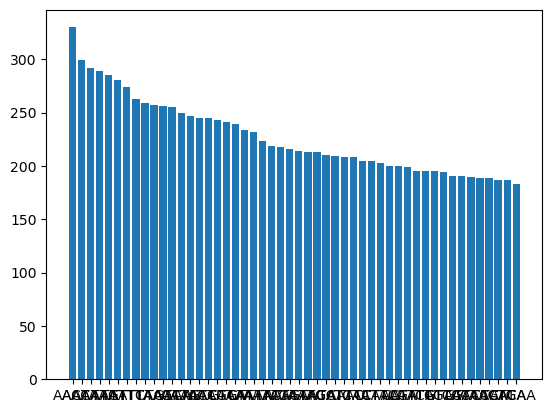

In [44]:
# k-mer Analysis Part 3 #
list_fourmers = fourmers.items() #Transfor Dic. to List#
ranked_list_fourmers = sorted(list_fourmers, key = lambda item : item[1],reverse=True) #Rank the frequency of 4-mers from high to low#
ranked_50_list_fourmers = ranked_list_fourmers[:50] #sort out top 50 frequency of 4-mers#

# draw the plot according to "ranked_50_list_fourmers" #
import matplotlib.pyplot as plt
x = [item[0] for item in ranked_50_list_fourmers] #x-axis#
y = [item[1] for item in ranked_50_list_fourmers] #y-axis#
plt.bar(x,y)
plt.show()

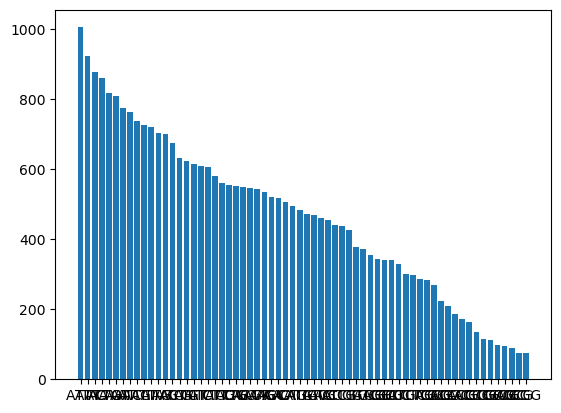

In [45]:
# k-mer Analysis Part 4 #
list_threemers = threemers.items()
ranked_list_threemers = sorted(list_threemers, key = lambda item : item[1],reverse=True) # same method as part 3#

#draw plot (also the same as done in part 3)#
import matplotlib.pyplot as plt
x = [item[0] for item in ranked_list_threemers]
y = [item[1] for item in ranked_list_threemers]
plt.bar(x,y)
plt.show()

In [46]:
# Translation Part 1 #
# Define a dictionary named Translation that inclueds all proteins and the codons #
translation_codon = {'UUU':'F',
                    'UUC':'F',
                    'UUA':'L',
                    'UUG':'L',
                    'CUU':'L',
                    'CUC':'L',
                    'CUA':'L',
                    'CUG':'L',
                    'AUU':'I',
                    'AUC':'I',
                    'AUA':'I',
                    'AUG':'M',
                    'GUU':'V',
                    'GUC':'V',
                    'GUA':'V',
                    'GUG':'V',
                    'UCU':'S',
                    'UCC':'S',
                    'UCA':'S',
                    'UCG':'S',
                    'CCU':'P',
                    'CCC':'P',
                    'CCA':'P',
                    'CCG':'P',
                    'ACU':'T',
                    'ACC':'T',
                    'ACA':'T',
                    'ACG':'T',
                    'GCU':'A',
                    'GCC':'A',
                    'GCA':'A',
                    'GCG':'A',
                    'UAU':'Y',
                    'UAC':'Y',
                    'UAA':'', # Stop Codon #
                    'UAG':'', # Stop Codon #
                    'CAU':'H',
                    'CAC':'H',
                    'CAA':'Q',
                    'CAG':'Q',
                    'AAU':'N',
                    'AAC':'N',
                    'AAA':'K',
                    'AAG':'K',
                    'GAU':'D',
                    'GAC':'D',
                    'GAA':'E',
                    'GAG':'E',
                    'UGU':'C',
                    'UGC':'C',
                    'UGA':'', # Stop Codon #
                    'UGG':'W',
                    'CGU':'R',
                    'CGC':'R',
                    'CGA':'R',
                    'CGG':'R',
                    'AGU':'S',
                    'AGC':'S',
                    'AGA':'R',
                    'AGG':'R',
                    'GGU':'G',
                    'GGC':'G',
                    'GGA':'G',
                    'GGG':'G'}

aminoacid_sequence_dictionary = {}

for transcriptome_name, transcriptome_rna_sequence in transcriptome_rna_dictionary.items():
    aminoacid_sequence = ""
    for i in range(0,len(transcriptome_rna_sequence)//3,3):
        codon = transcriptome_rna_sequence[i:i+3]
        aminoacid = translation_codon[codon]
        aminoacid_sequence += aminoacid
    aminoacid_sequence_dictionary[transcriptome_name] = aminoacid_sequence

print(aminoacid_sequence_dictionary)

# Extract Gene S from the dictionary created above #
print("Squence of Gene S: ",aminoacid_sequence_dictionary["S"])

{'ORF1ab': 'MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAPHGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRKVLLRKNGNKGAGGHSYGADLKSFDLGDELGTDPYEDFQENWNTKHSSGVTRELMRELNGGAYTRYVDNNFCGPDGYPLECIKDLLARAGKASCTLSEQLDFIDTKRGVYCCREHEHEIAWYTERSEKSYELQTPFEIKLAKKFDTFNGECPNFVFPLNSIIKTIQPRVEKKKLDGFMGRIRSVYPVASPNECNQMCLSTLMKCDHCGETSWQTGDFVKATCEFCGTENLTKEGATTCGYLPQNAVVKIYCPACHNSEVGPEHSLAEYHNESGLKTILRKGGRTIAFGGCVFSYVGCHNKCAYWVPRASANIGCNHTGVVGEGSEGLNDNLLEILQKEKVNINIVGDFKLNEEIAIILASFSASTSAFVETVKGLDYKAFKQIVESCGNFKVTKGKAKKGAWNIGEQKSILSPLYAFASEAARVVRSIFSRTLETAQNSVRVLQKAAITILDGISQYSLRLIDAMMFTSDLATNNLVVMAYITGGVVQLTSQWLTNIFGTVYEKLKPVLDWLEEKFKEGVEFLRDGWEIVKFISTCACEIVGGQIVTCAKEIKESVQTFFKLVNKFLALCADSIIIGGAKLKALNLGETFVTHSKGLYRKCVKSREETGLLMPLKAPKEIIFLEGETLPTEVLTEEVVLKTGDLQPLEQPTSEAVEAPLVGTPVCINGLMLLEIKDTEKYCALAPNMMVTNNTFTLKGGAPTKVTFGDDTVIEVQGYKSVNITFELDERIDKVLNEKCSAYTVELGTEVNEFACVVADAVIKTLQPVSELLTPLGIDLDEWSMATYYLFDESGEFKLASHMYCSFYPPDEDEEEGDCEEEEFEPSTQYEYGTEDDYQGKPLEFGATSAALQPEEEQEEDWLDDDSQQTV

        Gene Aminoacid
0     ORF1ab         M
1     ORF1ab         E
2     ORF1ab         S
3     ORF1ab         L
4     ORF1ab         V
...      ...       ...
3250   ORF10         F
3251   ORF10         P
3252   ORF10         F
3253   ORF10         T
3254   ORF10         I

[3255 rows x 2 columns]
Aminoacid    A   C    D    E   F    G   H    I    K    L   M    N   P   Q   R  \
Gene                                                                            
E            1   0    0    2   4    1   0    1    0    4   1    1   0   0   0   
M            6   2    1    3   6    2   0    7    3   15   1    5   1   2   3   
N            9   0    8    4   4   20   1    6    6    7   2   11  11   8  13   
ORF10        1   0    0    0   3    1   0    2    0    0   1    1   1   0   0   
ORF1ab     147  64  110  177  97  153  43  120  173  229  39  121  96  80  58   
ORF3a        8   1    3    1   7    5   1    8    6   13   2    1   3   4   3   
ORF6         1   0    1    1   2    0   1    4    0

<Axes: xlabel='Gene'>

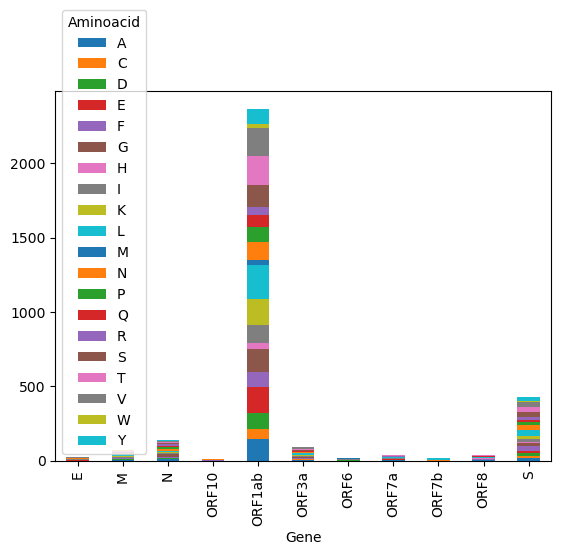

In [47]:
# Translation Part 2 #
# draw a bar chart of ami #no acid composition per transcript #
import pandas as pd # for dataframe #
import matplotlib.pyplot as plt # for chart drawing #

dataframe = [] #creat a new dataframe]
for transcriptome_name,aminoacid_sequence in aminoacid_sequence_dictionary.items():
    for single_aminoacid in aminoacid_sequence:
        dataframe.append({"Gene":transcriptome_name,"Aminoacid":single_aminoacid})
        
df_1 = pd.DataFrame(dataframe)
print(df_1)

# Calculate the frequency of each aminoacid in each gene and integrate them to new df_2 
df_2 = df.pivot_table(index="Gene",columns="Aminoacid",aggfunc="size",fill_value=0)
print(df_2)

# draw the chart bar according to df_2 #
df_2.plot(kind="bar",stacked=True)